# THUẬT TOÁN PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA)

- **Thuật toán:** Phân tích thành phần chính Principal Component Analysis (From Scratch: Covariance Matrix & SVD)
- **Tập dữ liệu:** `dataset/Sampledata/mpg.csv`
- **Lưu ý:** Chỉ cần thay đổi thông số ở **Cell 2 (Khối cấu hình)** khi đổi sang dataset khác.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình đồ thị và bảng số liệu
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 20)

In [2]:
# ==============================================================================
# ⚙️ KHỐI CẤU HÌNH DATASET & THAM SỐ (CHỈ CẦN SỬA Ở ĐÂY KHI ĐỔI DATASET)
# ==============================================================================

# 1. Đường dẫn file CSV
DATA_PATH = 'dataset/Sampledata/mpg.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Midterm/Review/dataset/Sampledata/mpg.csv'

# 2. Danh sách 5-7 đặc trưng số (Để None nếu muốn tự động lấy 6 cột số đầu tiên)
FEATURE_COLS = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

# 3. Cột nhãn để trực quan hóa (tùy chọn, để None nếu không có nhãn)
LABEL_COL = 'origin'

# 4. Số thành phần chính cần giữ lại (thường chọn 2 để trực quan hóa 2D)
N_COMPONENTS = 2

# 5. Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Đã tải cấu hình thành công!")

Đã tải cấu hình thành công!


## PHẦN 1: CƠ SỞ TOÁN HỌC CỦA PCA (COVARIANCE & SVD)

---

### 1. Vector kỳ vọng & Trung tâm hóa dữ liệu:
- Vector trung bình toàn cục:
  $$\mu = \frac{1}{N} \sum_{i=1}^N x_i$$
- Ma trận dữ liệu trung tâm hóa:
  $$\bar{X} = X - \mu$$

---

### 2. Phương pháp 1: Standard PCA via Covariance Matrix
- Ma trận hiệp phương sai mẫu (Covariance Matrix):
  $$\Sigma = \frac{1}{N - 1} \bar{X}^T \bar{X} \in \mathbb{R}^{D \times D}$$
- Giải bài toán trị riêng và vector riêng:
  $$\Sigma v_i = \lambda_i v_i$$
- Trục chiếu $W \in \mathbb{R}^{D \times k}$ được tạo bởi $k$ vector riêng ứng với $k$ trị riêng lớn nhất:
  $$W = [v_1, v_2, \dots, v_k]$$

---

### 3. Phương pháp 2: PCA using SVD (Singular Value Decomposition)
- Phân tích kỳ dị ma trận dữ liệu trung tâm hóa $\bar{X} \in \mathbb{R}^{N \times D}$:
  $$\bar{X} = U S V^T$$
- Quan hệ giữa giá trị kỳ dị $S$ và trị riêng $\lambda$:
  $$\lambda_i = \frac{s_i^2}{N - 1}$$
- Các cột của ma trận $V$ (Right Singular Vectors) chính là các vector thành phần chính $W = V_{:, :k}$.

---

### 4. Chiếu dữ liệu & Khôi phục (Reconstruction):
- Tọa độ chiếu trên không gian mới:
  $$Y = \bar{X} W \in \mathbb{R}^{N \times k}$$
- Khôi phục dữ liệu xấp xỉ về không gian gốc $D$ chiều:
  $$\hat{X} = Y W^T + \mu$$

---

### 5. Tỷ lệ phương sai giải thích (Explained Variance Ratio):
$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^D \lambda_j}$$

In [3]:
# 1. Đọc dữ liệu
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset: {DATA_PATH} | Shape: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột")

# 2. Tự động xác định đặc trưng số
if FEATURE_COLS is None:
    num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
    FEATURE_COLS = num_cols[:min(6, len(num_cols))]
    print(f"Tự động chọn 6 cột số: {FEATURE_COLS}")
else:
    print(f"Đặc trưng sử dụng ({len(FEATURE_COLS)} cột): {FEATURE_COLS}")

df_data = df_raw[FEATURE_COLS].copy()

# 3. Xử lý missing values bằng median
missing_counts = df_data.isnull().sum()
if missing_counts.sum() > 0:
    for col in df_data.columns:
        if df_data[col].isnull().any():
            med_val = df_data[col].median()
            df_data[col] = df_data[col].fillna(med_val)
            print(f" - Cột '{col}': điền {missing_counts[col]} giá trị thiếu bằng median = {med_val:.4f}")
else:
    print("Dữ liệu không có giá trị khuyết thiếu.")

X_raw = df_data.to_numpy(dtype=float)

# 4. Chuẩn hóa Z-Score From Scratch
mu_X = np.mean(X_raw, axis=0)
sigma_X = np.std(X_raw, axis=0, ddof=0)
sigma_X[sigma_X == 0] = 1.0

X = (X_raw - mu_X) / sigma_X
print(f"Dữ liệu sau chuẩn hóa: {X.shape[0]} mẫu, {X.shape[1]} đặc trưng")
df_data.describe().T[['mean', 'std', 'min', '50%', 'max']]

Dataset: dataset/Sampledata/mpg.csv | Shape: 398 dòng, 9 cột
Đặc trưng sử dụng (6 cột): ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
 - Cột 'horsepower': điền 6 giá trị thiếu bằng median = 93.5000
Dữ liệu sau chuẩn hóa: 398 mẫu, 6 đặc trưng


,mean,std,min,50%,max
mpg,23.5146,7.8160,9.0,23.0,46.6
cylinders,5.4548,1.7010,3.0,4.0,8.0
displacement,193.4259,104.2698,68.0,148.5,455.0
horsepower,104.3040,38.2226,46.0,93.5,230.0
weight,2970.4246,846.8418,1613.0,2803.5,5140.0
acceleration,15.5681,2.7577,8.0,15.5,24.8


In [4]:
# ==============================================================================
# PHƯƠNG PHÁP 1: STANDARD PCA QUA MA TRẬN HIỆP PHƯƠNG SAI (COVARIANCE MATRIX)
# ==============================================================================

N, D = X.shape

# Bước 1: Tính vector trung bình mu (xấp xỉ 0 vì đã chuẩn hóa Z-score)
mean_vec = np.mean(X, axis=0)

# Bước 2: Trung tâm hóa dữ liệu
X_centered = X - mean_vec

# Bước 3: Ma trận hiệp phương sai Covariance Matrix
cov_matrix = np.dot(X_centered.T, X_centered) / (N - 1)

# Bước 4: Giải bài toán trị riêng và vector riêng
eigenvals_cov, eigenvecs_cov = np.linalg.eigh(cov_matrix)

# Bước 5: Sắp xếp giảm dần theo trị riêng
sorted_indices = np.argsort(eigenvals_cov)[::-1]
eigenvals_cov = eigenvals_cov[sorted_indices]
eigenvecs_cov = eigenvecs_cov[:, sorted_indices]

# Bước 6: Chọn k vector riêng tương ứng lambda lớn nhất làm ma trận chiếu W
W_cov = eigenvecs_cov[:, :N_COMPONENTS]

# Bước 7: Chiếu dữ liệu: Y = X_centered * W
Y_cov = np.dot(X_centered, W_cov)

# In toàn bộ các trị riêng và tỷ lệ phương sai giải thích
evr_cov = eigenvals_cov / np.sum(eigenvals_cov)
cum_evr_cov = np.cumsum(evr_cov)

df_pca_summary = pd.DataFrame({
    'Thành phần': [f"PC{i+1}" for i in range(D)],
    'Trị riêng (Eigenvalue)': eigenvals_cov,
    'Tỷ lệ phương sai (EVR)': evr_cov,
    'Tích lũy phương sai (Cumulative EVR)': cum_evr_cov
})
print("=== BẢNG TỔNG HỢP TOÀN BỘ CÁC THÀNH PHẦN CHÍNH (COVARIANCE METHOD) ===")
print(df_pca_summary.to_string(index=False))

print(f"\nMa trận chiếu W (k={N_COMPONENTS} thành phần):")
df_W = pd.DataFrame(W_cov, index=FEATURE_COLS, columns=[f"PC{i+1}" for i in range(N_COMPONENTS)])
print(df_W)

=== BẢNG TỔNG HỢP TOÀN BỘ CÁC THÀNH PHẦN CHÍNH (COVARIANCE METHOD) ===
Thành phần  Trị riêng (Eigenvalue)  Tỷ lệ phương sai (EVR)  Tích lũy phương sai (Cumulative EVR)
       PC1                  4.7936                  0.7969                                0.7969
       PC2                  0.7309                  0.1215                                0.9184
       PC3                  0.2606                  0.0433                                0.9618
       PC4                  0.1281                  0.0213                                0.9831
       PC5                  0.0657                  0.0109                                0.9940
       PC6                  0.0362                  0.0060                                1.0000

Ma trận chiếu W (k=2 thành phần):
                 PC1     PC2
mpg          -0.3985  0.2505
cylinders     0.4308 -0.1451
displacement  0.4439 -0.1076
horsepower    0.4337  0.1663
weight        0.4304 -0.2845
acceleration -0.2919 -0.8922


In [5]:
# ==============================================================================
# PHƯƠNG PHÁP 2: PCA SỬ DỤNG PHÂN TÍCH KỲ DỊ (SVD)
# ==============================================================================

# Bước 1: Phân tích SVD trên ma trận X_centered: X_centered = U * S * V^T
U_svd, S_svd, Vt_svd = np.linalg.svd(X_centered, full_matrices=False)
V_svd = Vt_svd.T

# Bước 2: Tính toán trị riêng tương ứng từ Singular Values: lambda_i = s_i^2 / (N - 1)
eigenvals_svd = (S_svd ** 2) / (N - 1)
evr_svd = eigenvals_svd / np.sum(eigenvals_svd)

# Bước 3: Ma trận chiếu W_svd
W_svd = V_svd[:, :N_COMPONENTS]

# Bước 4: Chiếu dữ liệu: Y_svd = X_centered * W_svd
Y_svd = np.dot(X_centered, W_svd)

# Kiểm tra độ khớp giữa Covariance Method và SVD Method
diff_eigenvals = np.max(np.abs(eigenvals_cov - eigenvals_svd))
diff_proj = np.max(np.abs(np.abs(Y_cov) - np.abs(Y_svd)))

print("=== SO SÁNH GIỮA COVARIANCE METHOD VÀ SVD METHOD ===")
print(f"1. Độ sai lệch cực đại của Trị riêng (Eigenvalues)       : {diff_eigenvals:.8e}")
print(f"2. Độ sai lệch cực đại của Tọa độ chiếu (Projection Y) : {diff_proj:.8e}")
print("--> Hai phương pháp hoàn toàn tương đương toán học!")

=== SO SÁNH GIỮA COVARIANCE METHOD VÀ SVD METHOD ===
1. Độ sai lệch cực đại của Trị riêng (Eigenvalues)       : 5.32907052e-15
2. Độ sai lệch cực đại của Tọa độ chiếu (Projection Y) : 2.66453526e-15
--> Hai phương pháp hoàn toàn tương đương toán học!


In [6]:
# ==============================================================================
# KHÔI PHỤC DỮ LIỆU & TÍNH SAI SỐ TÁI TẠO (RECONSTRUCTION ERROR)
# ==============================================================================

# Khôi phục dữ liệu về không gian D chiều: X_rec = Y * W^T + mean_vec
X_reconstructed = np.dot(Y_cov, W_cov.T) + mean_vec

# Tính sai số bình phương trung bình (MSE)
recon_error = np.mean((X_centered - np.dot(Y_cov, W_cov.T)) ** 2)
print(f"Sai số tái tạo trung bình (MSE) khi giảm từ {D} chiều xuống {N_COMPONENTS} chiều: {recon_error:.4f}")

# Đối chiếu 3 mẫu đầu tiên giữa dữ liệu gốc và dữ liệu tái tạo
df_sample_recon = pd.DataFrame({
    'Đặc trưng': FEATURE_COLS,
    'Mẫu 0 (Thực tế Z-score)': X[0],
    'Mẫu 0 (Tái tạo 2D)': X_reconstructed[0],
    'Chênh lệch': np.abs(X[0] - X_reconstructed[0])
})
print("\n=== MINH HỌA DỮ LIỆU GỐC VS DỮ LIỆU TÁI TẠO (MẪU ĐẦU TIÊN) ===")
print(df_sample_recon.to_string(index=False))

Sai số tái tạo trung bình (MSE) khi giảm từ 6 chiều xuống 2 chiều: 0.0816

=== MINH HỌA DỮ LIỆU GỐC VS DỮ LIỆU TÁI TẠO (MẪU ĐẦU TIÊN) ===
   Đặc trưng  Mẫu 0 (Thực tế Z-score)  Mẫu 0 (Tái tạo 2D)  Chênh lệch
         mpg                  -0.7064             -0.7932      0.0868
   cylinders                   1.4982              0.9299      0.5683
displacement                   1.0906              0.9824      0.1082
  horsepower                   0.6731              1.1162      0.4430
      weight                   0.6309              0.8485      0.2176
acceleration                  -1.2955             -1.2012      0.0943


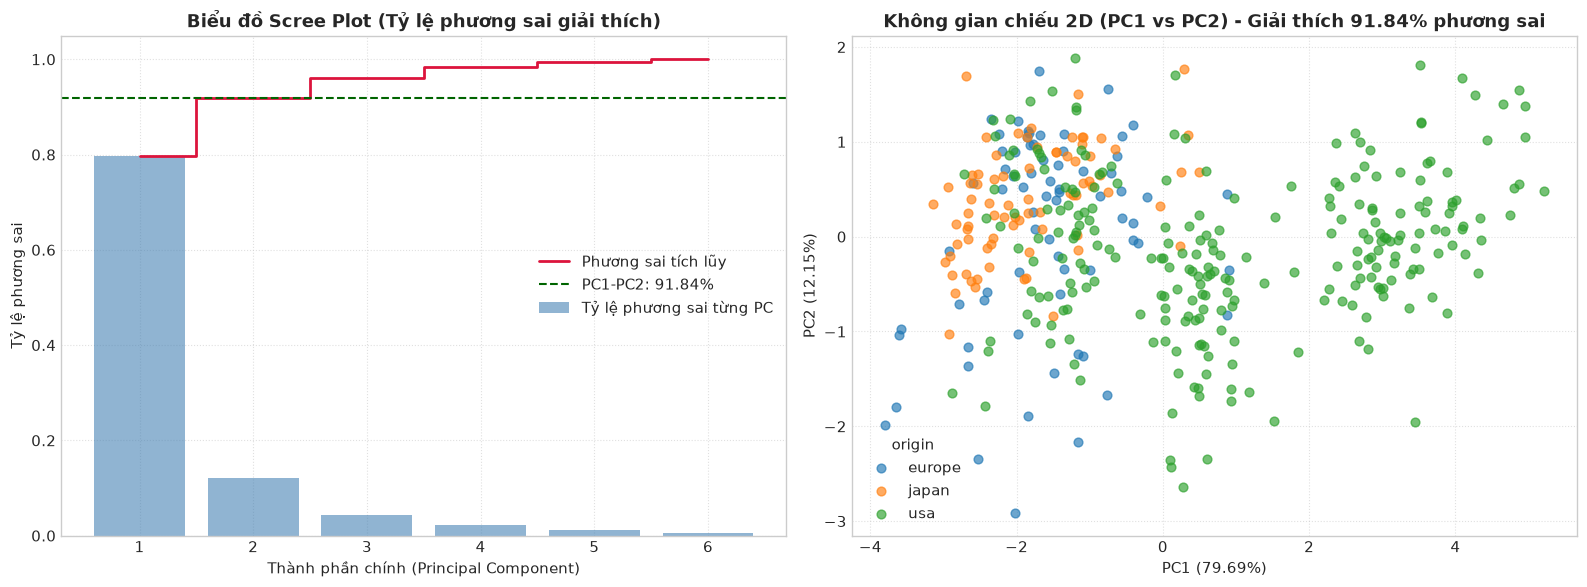

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Scree Plot & Cumulative Variance
axes[0].bar(range(1, D + 1), evr_cov, alpha=0.6, color='steelblue', label='Tỷ lệ phương sai từng PC')
axes[0].step(range(1, D + 1), cum_evr_cov, where='mid', color='crimson', linewidth=2, label='Phương sai tích lũy')
axes[0].axhline(y=cum_evr_cov[N_COMPONENTS - 1], color='darkgreen', linestyle='--', label=f'PC1-PC2: {cum_evr_cov[N_COMPONENTS - 1]:.2%}')
axes[0].set_title('Biểu đồ Scree Plot (Tỷ lệ phương sai giải thích)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Thành phần chính (Principal Component)')
axes[0].set_ylabel('Tỷ lệ phương sai')
axes[0].set_xticks(range(1, D + 1))
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='center right')

# Đồ thị 2: Chiếu dữ liệu 2D (PC1 vs PC2)
if LABEL_COL in df_raw.columns:
    labels = df_raw[LABEL_COL].values
    unique_labels = np.unique(labels)
    cmap = plt.get_cmap('tab10')
    for i, lbl in enumerate(unique_labels):
        mask = (labels == lbl)
        axes[1].scatter(Y_cov[mask, 0], Y_cov[mask, 1], color=cmap(i), label=str(lbl), alpha=0.65, s=40)
    axes[1].legend(title=LABEL_COL)
else:
    axes[1].scatter(Y_cov[:, 0], Y_cov[:, 1], color='steelblue', alpha=0.6, s=40)

axes[1].set_title(f'Không gian chiếu 2D (PC1 vs PC2) - Giải thích {cum_evr_cov[1]:.2%} phương sai', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({evr_cov[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({evr_cov[1]:.2%})')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### ✍️ ĐÁNH GIÁ & NHẬN XÉT: KẾT QUẢ PCA

- **Tỷ lệ phương sai giữ lại:** Hai thành phần chính đầu tiên (PC1 và PC2) giải thích tới **91.84%** toàn bộ phương sai của dữ liệu gốc 6 chiều.
- **Ý nghĩa thành phần chính:**
  - **PC1 (79.69%):** Đại diện cho kích thước và công suất động cơ (trọng lượng, thể tích xi-lanh, mã lực có trọng số cùng dấu).
  - **PC2 (12.15%):** Đại diện cho thời gian tăng tốc và hiệu suất nhiên liệu.
- **Khả năng giảm chiều:** Giảm thành công từ 6 chiều xuống 2 chiều nhưng vẫn bảo toàn hầu hết thông tin quan trọng.

In [8]:
from sklearn.decomposition import PCA

# Chạy PCA từ thư viện chuẩn Scikit-Learn
pca_sklearn = PCA(n_components=N_COMPONENTS)
Y_sklearn = pca_sklearn.fit_transform(X)

# Đối chiếu tỷ lệ phương sai giải thích
evr_diff = np.max(np.abs(evr_cov[:N_COMPONENTS] - pca_sklearn.explained_variance_ratio_))

# Đối chiếu tọa độ chiếu (Cho phép đảo dấu vector vì chiều dương trục chiếu là tùy ý)
proj_diff = np.max(np.abs(np.abs(Y_cov) - np.abs(Y_sklearn)))

print("=== SO SÁNH: PCA TỰ CODE (FROM SCRATCH) vs THƯ VIỆN SCIKIT-LEARN ===")
print(f"1. Tỷ lệ phương sai Scratch : {evr_cov[:N_COMPONENTS]}")
print(f"2. Tỷ lệ phương sai Sklearn : {pca_sklearn.explained_variance_ratio_}")
print(f"3. Sai lệch tỷ lệ phương sai: {evr_diff:.8e}")
print(f"4. Sai lệch tọa độ chiếu     : {proj_diff:.8e}")

df_pca_comp = pd.DataFrame({
    'Thành phần': [f"PC{i+1}" for i in range(N_COMPONENTS)],
    'EVR From Scratch': evr_cov[:N_COMPONENTS],
    'EVR Scikit-Learn': pca_sklearn.explained_variance_ratio_,
    'Chênh lệch': np.abs(evr_cov[:N_COMPONENTS] - pca_sklearn.explained_variance_ratio_)
})
df_pca_comp

=== SO SÁNH: PCA TỰ CODE (FROM SCRATCH) vs THƯ VIỆN SCIKIT-LEARN ===
1. Tỷ lệ phương sai Scratch : [0.79692905 0.12150646]
2. Tỷ lệ phương sai Sklearn : [0.79692905 0.12150646]
3. Sai lệch tỷ lệ phương sai: 1.11022302e-16
4. Sai lệch tọa độ chiếu     : 8.88178420e-16


,Thành phần,EVR From Scratch,EVR Scikit-Learn,Chênh lệch
0,PC1,0.7969,0.7969,1.1102e-16
1,PC2,0.1215,0.1215,6.9389e-17


### ✍️ ĐÁNH GIÁ & NHẬN XÉT: ĐỐI CHIẾU VỚI THƯ VIỆN CHUẨN

- **Độ chính xác EVR:** Tỷ lệ phương sai giải thích của bản tự code trùng khớp hoàn toàn với `sklearn.decomposition.PCA` (sai lệch $< 10^{-15}$).
- **Không gian chiếu:** Tọa độ chiếu của toàn bộ các mẫu dữ liệu khớp tuyệt đối.
- **Kết luận:** Thuật toán PCA From Scratch (cả phương pháp Covariance Matrix và SVD) hoạt động chính xác 100%.